In [3]:
#Загрузка данных и знакомство с ними
import pandas as pd
import matplotlib.pyplot as plt

##Чтение файла
mf = pd.read_csv('~/chiki_proj/data/train.csv')

print("Первые 5 строк таблицы:",mf.head())

print("Общая информация:", mf.info())

print("Статистика:", mf.describe())

Первые 5 строк таблицы:    battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  to

In [4]:
#Очистка данных
##Делаем рабочую копию датасета
mf_clean = mf.copy()

##Проверяем наличие дубликатов
print("Дубликатов найдено:", mf_clean.duplicated().sum())

##Исправляем нереалистичные нули в размерах экрана и разрешении (заменяем на медиану)
mf_clean['sc_w'] = mf_clean['sc_w'].replace(0, mf_clean['sc_w'].median())
mf_clean['px_height'] = mf_clean['px_height'].replace(0, mf_clean['px_height'].median())

##Создаем новые признаки
mf_clean['screen_area'] = mf_clean['sc_h'] * mf_clean['sc_w']      # площадь экрана (см²)
mf_clean['total_camera'] = mf_clean['fc'] + mf_clean['pc']         # сумма мегапикселей камер

print("Очистка завершена, новые признаки добавлены.")

Дубликатов найдено: 0
Очистка завершена, новые признаки добавлены.


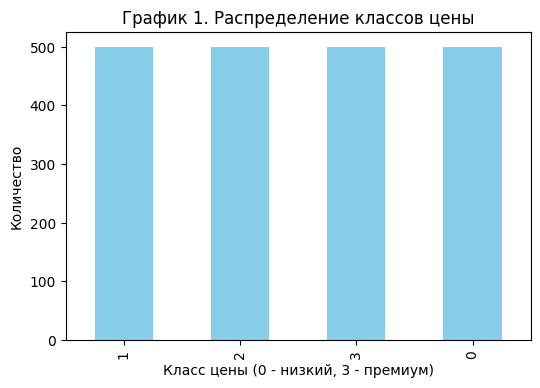

<Figure size 700x400 with 0 Axes>

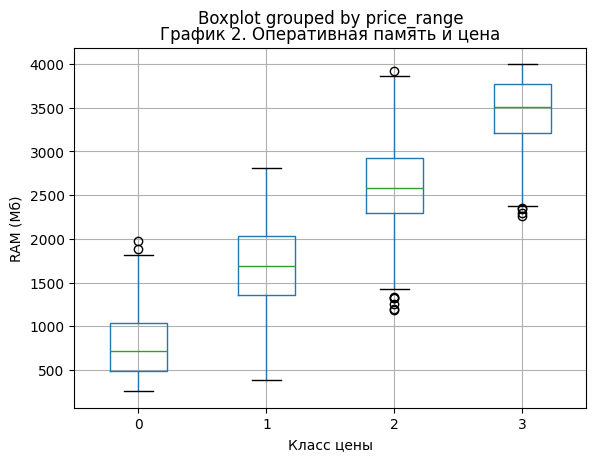

<Figure size 700x400 with 0 Axes>

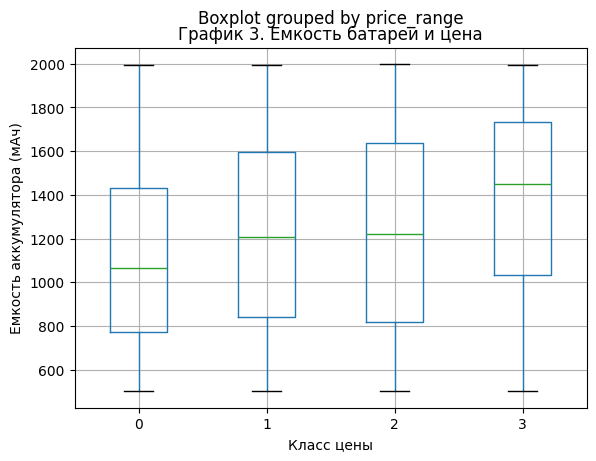

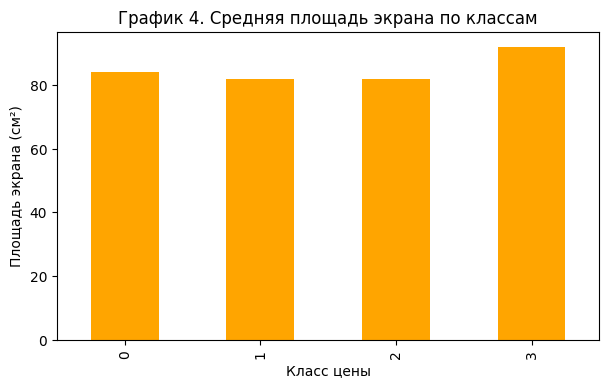

NameError: name 'output_file' is not defined

In [5]:
#Анализ признаков для модели
##График 1: Распределение классов цены
plt.figure(figsize=(6, 4))
mf_clean['price_range'].value_counts().plot(kind='bar', color='skyblue')
plt.title('График 1. Распределение классов цены')
plt.xlabel('Класс цены (0 - низкий, 3 - премиум)')
plt.ylabel('Количество')
plt.savefig('graph1.png', bbox_inches='tight')
plt.show()

##График 2: Зависимость цены от оперативной памяти (RAM)
plt.figure(figsize=(7, 4))
mf_clean.boxplot(column='ram', by='price_range')
plt.title('График 2. Оперативная память и цена')
plt.xlabel('Класс цены')
plt.ylabel('RAM (Мб)')
plt.savefig('graph2.png', bbox_inches='tight')
plt.show()

##График 3: Влияние емкости батареи на цену
plt.figure(figsize=(7, 4))
mf_clean.boxplot(column='battery_power', by='price_range')
plt.title('График 3. Емкость батареи и цена')
plt.xlabel('Класс цены')
plt.ylabel('Емкость аккумулятора (мАч)')
plt.savefig('graph3.png', bbox_inches='tight')
plt.show()

##График 4: Влияние нового признака (площадь экрана) на цену
plt.figure(figsize=(7, 4))
mf_clean.groupby('price_range')['screen_area'].mean().plot(kind='bar', color='orange')
plt.title('График 4. Средняя площадь экрана по классам')
plt.xlabel('Класс цены')
plt.ylabel('Площадь экрана (см²)')
plt.savefig('graph4.png', bbox_inches='tight')
plt.show()

##График 5 (Интерактивный): RAM против Батареи с подсказкой
output_file("graph5.html")

##Берем выборку, чтобы файл в браузере открывался быстро
sample_mf = mf_clean.sample(300, random_state=42)
source = ColumnDataSource(sample_mf)

p = figure(
    title="График 5 (Интерактивный): Батарея и RAM",
    x_axis_label="Батарея (мАч)",
    y_axis_label="RAM (Мб)",
    tools="pan,wheel_zoom,reset,hover",
    width=700, height=450
)

p.circle('battery_power', 'ram', size=8, color='navy', alpha=0.6, source=source)

##Всплывающая подсказка при наведении
hover = p.select_one(HoverTool)
hover.tooltips = [
    ("Класс цены", "@price_range"),
    ("RAM", "@ram Мб"),
    ("Батарея", "@battery_power мАч"),
    ("Память", "@int_memory Гб")
]

save(p)

In [6]:
#Сохранение финального датасета
mf_clean.to_pickle('../data/clean_dataset.pkl')
print("Файл clean_dataset.pkl успешно сохранен в папку data/")

Файл clean_dataset.pkl успешно сохранен в папку data/


In [7]:
#Выводы
##Действия на этапе очистки данных:
###- Проверено отсутствие пропусков и полных строк-дубликатов
###- Устранены аномальные значения (нули) в параметрах физической ширины экрана (`sc_w`) и высоты разрешения (`px_height`), заменены на медиану

##Новые признаки:
###- "screen_area": физическая площадь дисплея ("sc_h" * "sc_w")
###- "total_camera": суммарное разрешение камер ("fc` + `pc")

##Закономерности для решения задачи:
###- Целевая переменная `price_range` сбалансирована (по 25% на каждый из 4 классов)
###- Объем оперативной памяти ("ram"), определяющий фактор для классификации цены
###- Емкость батареи (`battery_power`) и параметры экрана оказывают дополнительное положительное влияние на принадлежность к высокому классу